In [56]:
import glob
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os

from astropy.io import fits
from astropy.constants import c
from astropy.table import QTable

import pyimfit
import pandas as pd

import argparse
from pathlib import Path

import astropy.units as u
import subprocess
import traceback as tb
import sys
import json

from parse_results import *
from astropy.visualization import quantity_support

In [57]:

master_table = QTable.read("/home/ryans/Projects/Photometric Decomp/Analysis/master_table.csv", data_start=2)
master_table["NAME"] = master_table['\ufeffNAME']
master_table = master_table.to_pandas()

In [43]:
p = Path("/home/ryans/Projects/Photometric Decomp/Outputs/RESULTS_OF_DECOMPOSITION/")
SGAtable = QTable.read(os.path.join("/home/ryans/Projects/Photometric Decomp/Analysis/", "SGA-2020.fits"))
# master_table = astropy.io.ascii.read("/home/ryans/Projects/Photometric Decomp/Analysis/master_table.csv")
galmarks = json.load(open(os.path.join(p, "galmarks.json")))

total_bad_fit = 0
total_fit = 0
bound_sticking = 0

galaxies = []
bands = ["g", "r"]

structure = os.walk(p)
for root, dirs, files in structure:
    if len(glob.glob(os.path.join(root,"*.fits"))) != 0: # Check to see if we have entered a folder with galaxy data
        galaxies.append([Path(root).resolve(), os.path.basename(os.path.dirname(root))])

fit_type = "2_sersic"

all_results =  get_all_results(galaxies, bands, fit_type, galmarks)
total_fit = len(all_results.groups.indices)

thresh = 1
total_bad_fit = len(all_results[all_results["Reduced ChiSq"] > thresh].groups.indices)

print(f"Total fit: {total_fit}")
print(f"Total poor fit: {total_bad_fit} ({total_bad_fit/total_fit * 100:.2f}% bad)")
print(f"Total parameter bounds sticking: {bound_sticking}")

Couldn't read /home/ryans/Projects/Photometric Decomp/Outputs/RESULTS_OF_DECOMPOSITION/Isaac Jensen/PR/PGC1302609/2_sersic_g_fit_params.txt
Couldn't read /home/ryans/Projects/Photometric Decomp/Outputs/RESULTS_OF_DECOMPOSITION/Isaac Jensen/PR/PGC1302609/2_sersic_r_fit_params.txt
Couldn't read /home/ryans/Projects/Photometric Decomp/Outputs/RESULTS_OF_DECOMPOSITION/Isaac Jensen/PR/PGC087192/2_sersic_g_fit_params.txt
Couldn't read /home/ryans/Projects/Photometric Decomp/Outputs/RESULTS_OF_DECOMPOSITION/Isaac Jensen/PR/PGC087192/2_sersic_r_fit_params.txt
Couldn't read /home/ryans/Projects/Photometric Decomp/Outputs/RESULTS_OF_DECOMPOSITION/Isaac Jensen/PR/SDSSJ112116.84+425257.6/2_sersic_r_fit_params.txt
Couldn't read /home/ryans/Projects/Photometric Decomp/Outputs/RESULTS_OF_DECOMPOSITION/Isaac Jensen/PR/2MASXJ13134170+5716095/2_sersic_r_fit_params.txt
Couldn't read /home/ryans/Projects/Photometric Decomp/Outputs/RESULTS_OF_DECOMPOSITION/Isaac Jensen/PR/PGC386442/2_sersic_g_fit_params.tx

In [44]:
# all_results

## Plotting

In [45]:
type_colors = {
    "PR": "red",
    "PB": "green",
    "PH": "blue"
}
type_ls = {
    "PR": "-",
    "PB": "--",
    "PH": "-."
}
gal_types = ["PR", "PH", "PB"]
linewidth = 1.5
dpi = 300

### Flux or Luminosity Ratio

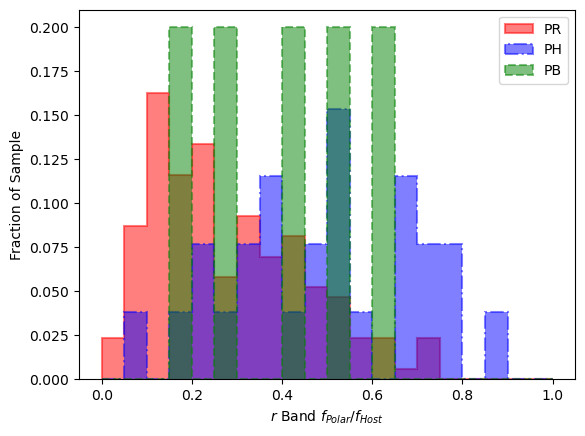

In [46]:
# a = all_results[all_results["Function Label"] == "Host"]
# plt.hist(a["Flux Ratio"])
fig = plt.Figure(dpi=dpi)
ngals = np.size(np.unique(all_results["Galaxy Name"]))

for gal_type in gal_types:
    a = all_results[(all_results["Function Label"] == "Polar") & (all_results["Galaxy Type"]==gal_type) & (all_results["band"] == "r")]
    bins = np.arange(0, 1 + 0.05, 0.05)
    val, bins = np.histogram(a["Flux Ratio"], bins=bins)
    plt.stairs(val/len(a), edges=bins, color=type_colors[gal_type], edgecolor=type_colors[gal_type], ls=type_ls[gal_type], label=gal_type, linewidth=linewidth, fill=True, alpha=0.5)

plt.xlabel(r"$r$ Band ${f_{Polar}}/{f_{Host}}$")
plt.ylabel("Fraction of Sample")
plt.legend()
plt.show()

In [47]:
master_table.columns
print([i for i in master_table.columns])

['\ufeffNAME', 'IAU_ID', 'ALT_NAME', 'RA', 'DEC', 'PSG_TYPE_1', 'PSG_TYPE_2', 'CATEGORY_1', 'CATEGORY_2', 'MORPHTYPE', 'EGIS', 'EGIPS', 'REFERENCE', 'LINKS', 'PGC', 'RA_LEDA', 'DEC_LEDA', 'MORPHTYPE_LEDA', 'D25_LEDA', 'REDSHIFT_LEDA', 'NED_NAME', 'REDSHIFT_NED', 'J_MAG_NED', 'H_MAG_NED', 'Ks_MAG_NED', 'SGA_ID', 'RA_SGA', 'DEC_SGA', 'G_MAG_SB26_SGA', 'G_MAG_SB26_ERR_SGA', 'R_MAG_SB26_SGA', 'R_MAG_SB26_ERR_SGA', 'Z_MAG_SB26_SGA', 'Z_MAG_SB26_ERR_SGA', 'D26_SGA', 'D26_REF', 'PHDEP_G', 'PHDEP_R', 'PHDEP_I', 'PHDEP_Z', 'PHDEP_GR', 'PHDEP_ALL', 'G_MAG_ASYM_IRAF', 'G_MAG_ASYM_ERR_IRAF', 'G_MAG_SB26_IRAF', 'R26_G_IRAF', 'R26_G_ERR_IRAF', 'G_MAG_OUTER_IRAF', 'R_G_IRAF', 'R_MAG_ASYM_IRAF', 'R_MAG_ASYM_ERR_IRAF', 'R_MAG_SB26_IRAF', 'R26_R_IRAF', 'R26_R_ERR_IRAF', 'R_MAG_OUTER_IRAF', 'R_R_IRAF', 'I_MAG_ASYM_IRAF', 'I_MAG_ASYM_ERR_IRAF', 'I_MAG_SB26_IRAF', 'R26_I_IRAF', 'R26_I_ERR_IRAF', 'I_MAG_OUTER_IRAF', 'R_I_IRAF', 'Z_MAG_ASYM_IRAF', 'Z_MAG_ASYM_ERR_IRAF', 'Z_MAG_SB26_IRAF', 'R26_Z_IRAF', 'R26_

### Abs mag

In [48]:
from astropy.cosmology import Planck18
import numpy as np

cosmo = Planck18

In [49]:
DLs = []
DAs = []
for galaxy_name in all_results["Galaxy Name"]:
    tab = master_table[master_table["NAME"] == galaxy_name].iloc[0]
    DLs.append(tab["DL"])
    DAs.append(tab["DA"])
all_results["DL"] = np.array(DLs) * u.Mpc
all_results["DA"] = np.array(DAs) * u.Mpc

all_results["App Mag"] = flux2ABmag(all_results["Flux"]) * u.mag
all_results["Abs Mag"] = all_results["App Mag"] - astropy.coordinates.Distance(all_results["DL"]).distmod
all_results = all_results[np.isfinite(all_results["DL"])]

In [50]:
SGAtable.columns
SGAtable = SGAtable[(SGAtable["Z_LEDA"] > 0) & (SGAtable["R_MAG_SB26"] != -1)]
SGAtable["R_ABSMAG_SB26"] = (SGAtable["R_MAG_SB26"] *u.mag - cosmo.distmod(SGAtable["Z_LEDA"])).value

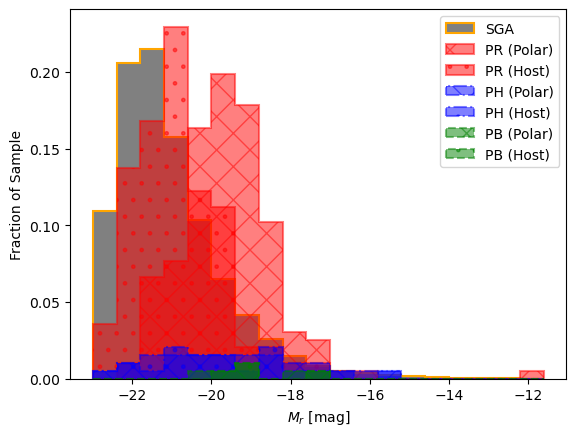

In [51]:
quantity_support()
fig = plt.Figure(dpi=dpi)
ngals = np.size(np.unique(all_results["Galaxy Name"]))

r = (-23, -12)
step = 0.6
bins = np.arange(r[0], r[1]+step, step) * u.mag

sgaval, bins = np.histogram(SGAtable["R_ABSMAG_SB26"] * u.mag, bins=bins)
plt.stairs(sgaval/len(SGAtable), edges=bins, color="grey", edgecolor="orange", ls="-", label=f"SGA", linewidth=linewidth, fill=True, alpha=1)

for gal_type in gal_types:
    polar = all_results[(all_results["Function Label"] == "Polar") & (all_results["Galaxy Type"]==gal_type) & (all_results["band"] == "r")]
    host = all_results[(all_results["Function Label"] == "Host") & (all_results["Galaxy Type"]==gal_type) & (all_results["band"] == "r")]
    # z = master_table["Z"]
    polar_absmag = polar["Abs Mag"]
    host_absmag = host["Abs Mag"]


    polval, bins = np.histogram(polar_absmag, bins=bins)
    plt.stairs(polval/ngals, edges=bins, color=type_colors[gal_type], edgecolor=type_colors[gal_type], ls=type_ls[gal_type], label=f"{gal_type} (Polar)", linewidth=linewidth, fill=True, alpha=0.5, hatch="X")

    hostval, bins = np.histogram(host_absmag, bins=bins)
    plt.stairs(hostval/ngals, edges=bins, color=type_colors[gal_type], edgecolor=type_colors[gal_type], ls=type_ls[gal_type], label=f"{gal_type} (Host)", linewidth=linewidth, fill=True, alpha=0.5, hatch=".")


plt.xlabel(r"$M_r$ [mag]")
plt.ylabel("Fraction of Sample")
plt.legend()
plt.show()

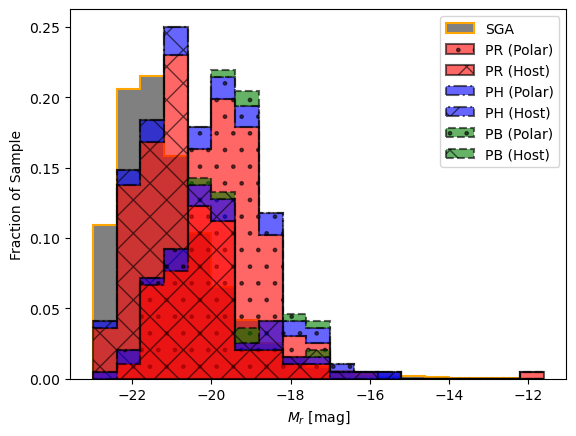

In [52]:
quantity_support()
fig = plt.Figure(dpi=dpi)
ngals = np.size(np.unique(all_results["Galaxy Name"]))

r = (-23, -12)
step = 0.6
bins = np.arange(r[0], r[1]+step, step) * u.mag

sgaval, bins = np.histogram(SGAtable["R_ABSMAG_SB26"] * u.mag, bins=bins)
plt.stairs(sgaval/len(SGAtable), edges=bins, color="grey", edgecolor="orange", ls="-", label=f"SGA", linewidth=linewidth, fill=True, alpha=1)

polar_absmags = []

baseline_host = np.zeros(np.size(bins)-1)
baseline_polar = np.zeros(np.size(bins)-1)
for gal_type in gal_types:
    polar = all_results[(all_results["Function Label"] == "Polar") & (all_results["Galaxy Type"]==gal_type) & (all_results["band"] == "r")]
    host = all_results[(all_results["Function Label"] == "Host") & (all_results["Galaxy Type"]==gal_type) & (all_results["band"] == "r")]
    # z = master_table["Z"]
    polar_absmag = polar["Abs Mag"]
    polar_absmags.append(polar_absmag)
    host_absmag = host["Abs Mag"]


    polval, bins = np.histogram(polar_absmag, bins=bins)
    plt.stairs(polval/ngals+baseline_polar, baseline=baseline_polar, edges=bins, color=type_colors[gal_type], edgecolor="black", ls=type_ls[gal_type], label=f"{gal_type} (Polar)", linewidth=linewidth, fill=True, alpha=0.6, hatch=".")
    baseline_polar += polval/ngals

    hostval, bins = np.histogram(host_absmag, bins=bins)
    plt.stairs(hostval/ngals+baseline_host,baseline=baseline_host, edges=bins, color=type_colors[gal_type], edgecolor="black", ls=type_ls[gal_type], label=f"{gal_type} (Host)", linewidth=linewidth, fill=True, alpha=0.6, hatch="X")
    baseline_host += hostval/ngals

# plt.hist(polar_absmags, stacked=True, label=gal_types, color=[type_colors[gal_type] for gal_type in gal_types])
plt.xlabel(r"$M_r$ [mag]")
plt.ylabel("Fraction of Sample")
plt.legend()
plt.show()

### 26th isophote radius

In [53]:
import scipy

In [54]:
def nmgyfluxSB_to_magSB(fluxSB):
    zero_point_star_equiv = u.zero_point_flux(3631.1 * u.Jy)
    return (fluxSB*u.arcsec**2).to(u.mag("AB"), zero_point_star_equiv).value * u.mag("AB/arcsec**2")

def nmgymagSB_to_fluxSB(magSB):
    zero_point_star_equiv = u.zero_point_flux(3631.1 * u.Jy)
    return (magSB.value*u.ABmag).to(u.nmgy, zero_point_star_equiv).value * u.nmgy/u.arcsec**2
x = 22.5 * u.mag("AB/arcsec**2")

nmgyfluxSB_to_magSB(nmgymagSB_to_fluxSB(x))

<Magnitude 22.5 mag(AB / arcsec2)>

In [66]:
def radius_of_isophote(mu_iso, mu_eff, n, r_eff):
    b_n = scipy.special.gammaincinv(2*n, 0.5)
    I_iso = nmgymagSB_to_fluxSB(mu_iso)
    I_eff = nmgymagSB_to_fluxSB(mu_eff)
    return r_eff * ((b_n-np.log(I_iso/I_eff))/b_n)**n

# Example: radius of the 26 mag/arcsec^2 isophote
mu_26 = 26* u.mag("AB/arcsec**2")
mu_e = 20.5 * u.mag("AB/arcsec**2")  # example effective surface brightness
n = 4.0
r_e = 60
r_26 = radius_of_isophote(mu_26, mu_e, n, r_e)
print(f"r_26 (semi-major axis) = {r_26:.2f}")

# quantity_support()
# plt.imshow(model(xx,yy), extent=(x[0],x[-1], y[0], y[-1]))

r_26 (semi-major axis) = 456.17


### Check with Photutils
Actually photutils seems to produce a generally worse result, but I think my alg works

In [ ]:
model = astropy.modeling.functional_models.Sersic2D(nmgymagSB_to_fluxSB(mu_e).value, r_eff=r_e, n=4, ellip=0.7)

sz = 100
x = np.linspace(-sz,sz,sz)
y = np.linspace(-sz,sz,sz)
xx,yy = np.meshgrid(x,y) 

In [58]:
from photutils.isophote import EllipseGeometry
geometry = EllipseGeometry(x0=sz/2, y0=sz/2, sma=20, eps=0.5,
                           pa=np.deg2rad(0))

(<matplotlib.patches.Ellipse at 0x7f44b5a21590>,)

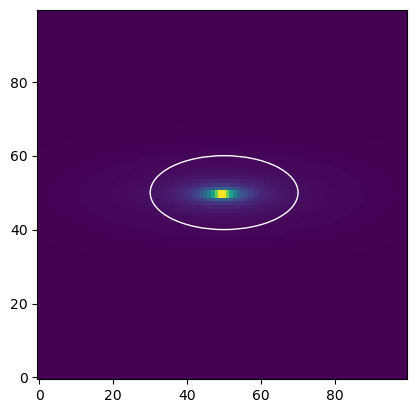

In [59]:
from photutils.aperture import EllipticalAperture
aper = EllipticalAperture((geometry.x0, geometry.y0), geometry.sma,
                          geometry.sma * (1 - geometry.eps),
                          theta=geometry.pa)
fig, ax = plt.subplots()
ax.imshow(model(xx,yy), origin='lower')
aper.plot(color='white')

/home/ryans/miniconda3/envs/phot-decomp/lib/python3.13/site-packages/astropy/modeling/functional_models.py:879: RuntimeWarning: invalid value encountered in power
  -cls._gammaincinv(2 * n, 0.5) * ((r / r_eff) ** (1 / n) - 1)
/home/ryans/miniconda3/envs/phot-decomp/lib/python3.13/site-packages/astropy/modeling/functional_models.py:879: RuntimeWarning: invalid value encountered in power
  -cls._gammaincinv(2 * n, 0.5) * ((r / r_eff) ** (1 / n) - 1)
/home/ryans/miniconda3/envs/phot-decomp/lib/python3.13/site-packages/astropy/modeling/functional_models.py:879: RuntimeWarning: invalid value encountered in power
  -cls._gammaincinv(2 * n, 0.5) * ((r / r_eff) ** (1 / n) - 1)
/home/ryans/miniconda3/envs/phot-decomp/lib/python3.13/site-packages/astropy/modeling/functional_models.py:879: RuntimeWarning: invalid value encountered in power
  -cls._gammaincinv(2 * n, 0.5) * ((r / r_eff) ** (1 / n) - 1)


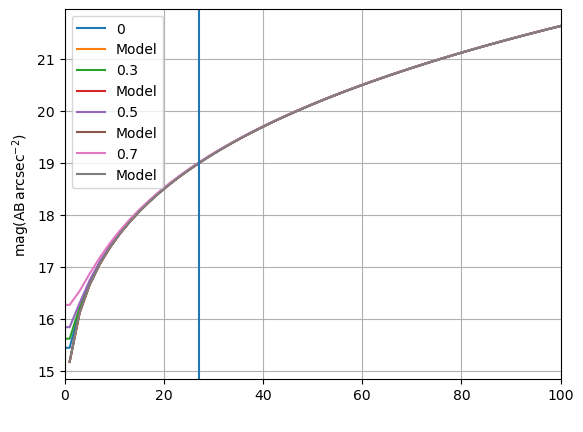

In [60]:
for ellip in [0, 0.3, 0.5, 0.7]:
    model = astropy.modeling.functional_models.Sersic2D(nmgymagSB_to_fluxSB(mu_e).value, r_eff=r_e, n=4, ellip=ellip)
    model2 = astropy.modeling.functional_models.Sersic1D(nmgymagSB_to_fluxSB(mu_e).value, r_eff=r_e, n=4)

    sz = 100
    x = np.linspace(-sz,sz,sz)
    y = np.linspace(-sz,sz,sz)
    xx,yy = np.meshgrid(x,y) 

    plt.plot(x, nmgyfluxSB_to_magSB(model(xx,yy)[int(sz/2),:] * u.nmgy/u.arcsec**2), label=ellip)
    # plt.plot(model(xx,yy)[:,int(sz/2)], label=ellip)
    plt.plot(x, nmgyfluxSB_to_magSB(model2(x) * u.nmgy/u.arcsec**2), label="Model")
plt.xlim([0,100])
plt.axvline(r_26_2)
plt.grid()
plt.legend()
plt.show()

In [61]:
from photutils.isophote import Ellipse
ellipse = Ellipse(model(xx,yy), geometry=geometry)
isolist = ellipse.fit_image()

In [63]:
t = isolist.to_table()
t["mag"] = nmgyfluxSB_to_magSB(t["intens"] * u.nmgy/u.arcsec**2)
# t["mag","sma"][:50]

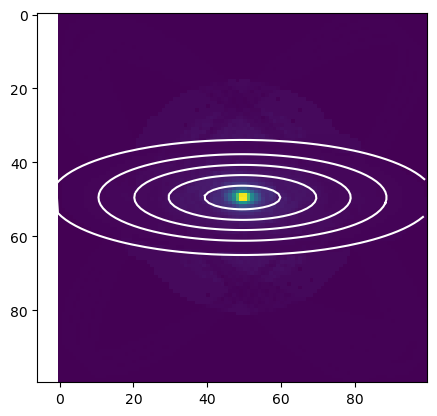

In [64]:
from photutils.isophote import build_ellipse_model
model_image = build_ellipse_model(model(xx,yy).shape, isolist)
plt.imshow(model_image)
smas = np.linspace(10, 50, 5)
for sma in smas:
    iso = isolist.get_closest(sma)
    x, y, = iso.sampled_coordinates()
    plt.plot(x, y, color='white')